## Config

In [ ]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"

global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

INDEX = 3

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

# CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
# control_dir = CONTROL_PERI_ROOT / 'target_A'
# control_npz_path = control_dir / FILE
# stim_npz = np.load(control_npz_path, allow_pickle=True)

print(stim_npz)

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122433
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_122433__bin20ms_sigma20ms.npz
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_122433__BR_004.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...


In [10]:
def peri_event_rates_from_peaks_ms(
    peaks_ms: dict[int, np.ndarray],
    event_times_ms: np.ndarray,
    win_ms=(-600.0, 600.0),
    bin_ms=20.0,
    sigma_ms=50.0,
):
    """
    Compute peri-event firing rates from spike times (ms).

    Args
    ----
    peaks_ms:
        dict {unit_id: spike_times_ms}
    event_times_ms:
        (n_events,) array of event times in ms (same timebase as peaks_ms)
    win_ms:
        (start_ms, end_ms) peri-event window relative to each event
    bin_ms:
        bin width in ms
    sigma_ms:
        Gaussian smoothing sigma in ms (0 disables smoothing)

    Returns
    -------
    rates_hz:
        (n_events, n_units, n_bins) smoothed peri-event rates in Hz
    centers_ms:
        (n_bins,) bin centers in ms relative to event
    unit_ids:
        list of unit_ids in the same order as axis=1
    """
    event_times_ms = np.asarray(event_times_ms, dtype=float).ravel()
    if event_times_ms.size == 0:
        raise ValueError("event_times_ms is empty.")

    unit_ids = sorted(peaks_ms.keys())
    n_units = len(unit_ids)
    if n_units == 0:
        raise ValueError("peaks_ms is empty.")

    w0, w1 = float(win_ms[0]), float(win_ms[1])
    if w1 <= w0:
        raise ValueError("win_ms must satisfy win_ms[1] > win_ms[0].")

    # Uniform bins across the full window
    edges_ms = np.arange(w0, w1 + bin_ms, bin_ms, dtype=float)
    centers_ms = edges_ms[:-1] + 0.5 * bin_ms
    n_bins = centers_ms.size

    # Allocate output
    rates = np.zeros((event_times_ms.size, n_units, n_bins), dtype=float)

    # Bin per event, per unit
    bin_s = bin_ms / 1000.0
    for ei, t0 in enumerate(event_times_ms):
        for ui, u in enumerate(unit_ids):
            st = np.asarray(peaks_ms[u], dtype=float)
            if st.size == 0:
                continue

            rel = st - t0  # ms relative to event
            # keep only spikes in window (saves time)
            rel = rel[(rel >= w0) & (rel < w1)]
            if rel.size == 0:
                continue

            counts, _ = np.histogram(rel, bins=edges_ms)
            rates[ei, ui] = counts / bin_s  # Hz

    # Gaussian smoothing along time axis (per event, per unit)
    if sigma_ms is not None and sigma_ms > 0:
        sigma_bins = sigma_ms / bin_ms
        r = int(np.ceil(4 * sigma_bins))
        k = np.arange(-r, r + 1, dtype=float)
        g = np.exp(-(k**2) / (2.0 * sigma_bins**2))
        g /= g.sum()

        # convolve along last axis
        # (simple and reliable; fast enough for typical n_events x n_units)
        sm = np.empty_like(rates)
        for ei in range(rates.shape[0]):
            for ui in range(rates.shape[1]):
                sm[ei, ui] = np.convolve(rates[ei, ui], g, mode="same")
        rates = sm

    return rates, centers_ms, unit_ids, edges_ms

## Plot matched filter spikes

In [30]:
THRESH = 4
template_dir = Path(REPO_ROOT / 'config' / "median_extremum_templates_norm.npy")
control_template = np.load(template_dir)
nbefore = np.argmin(control_template)
ms_before = nbefore / 30000 * 1000

In [31]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks
noise_levels = si.get_noise_levels(rec_nprw, method="mad", return_in_uV=False) # They didn't write return_in_uV in their documentation

nprw_peaks_mf = detect_peaks(
    rec_nprw,
    method="matched_filtering",
    method_kwargs=dict(
        detect_threshold=THRESH,
        peak_sign=PEAK_SIGN,
        ms_before=ms_before,
        prototype=control_template,
        radius_um=0,
    ),
    job_kwargs=dict(n_jobs=-1),
)

nprw_peak_samps_mf, nprw_peak_amps_mf = _parse_SI_peaks(nprw_peaks_mf, 128)
nprw_peak_ms_mf   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps_mf.items()}


noise_level (workers: 12 processes fork):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (matched_filtering) (workers: 12 processes fork):   0%|          | 0/18 [00:00<?, ?it/s]

In [32]:
np.ceil(nprw_peaks_si_obj["ir_ms"])

array([ 8275., 13436., 17880., 22650., 28393., 33266., 38158., 42718.,
       47661., 54762., 60093.])

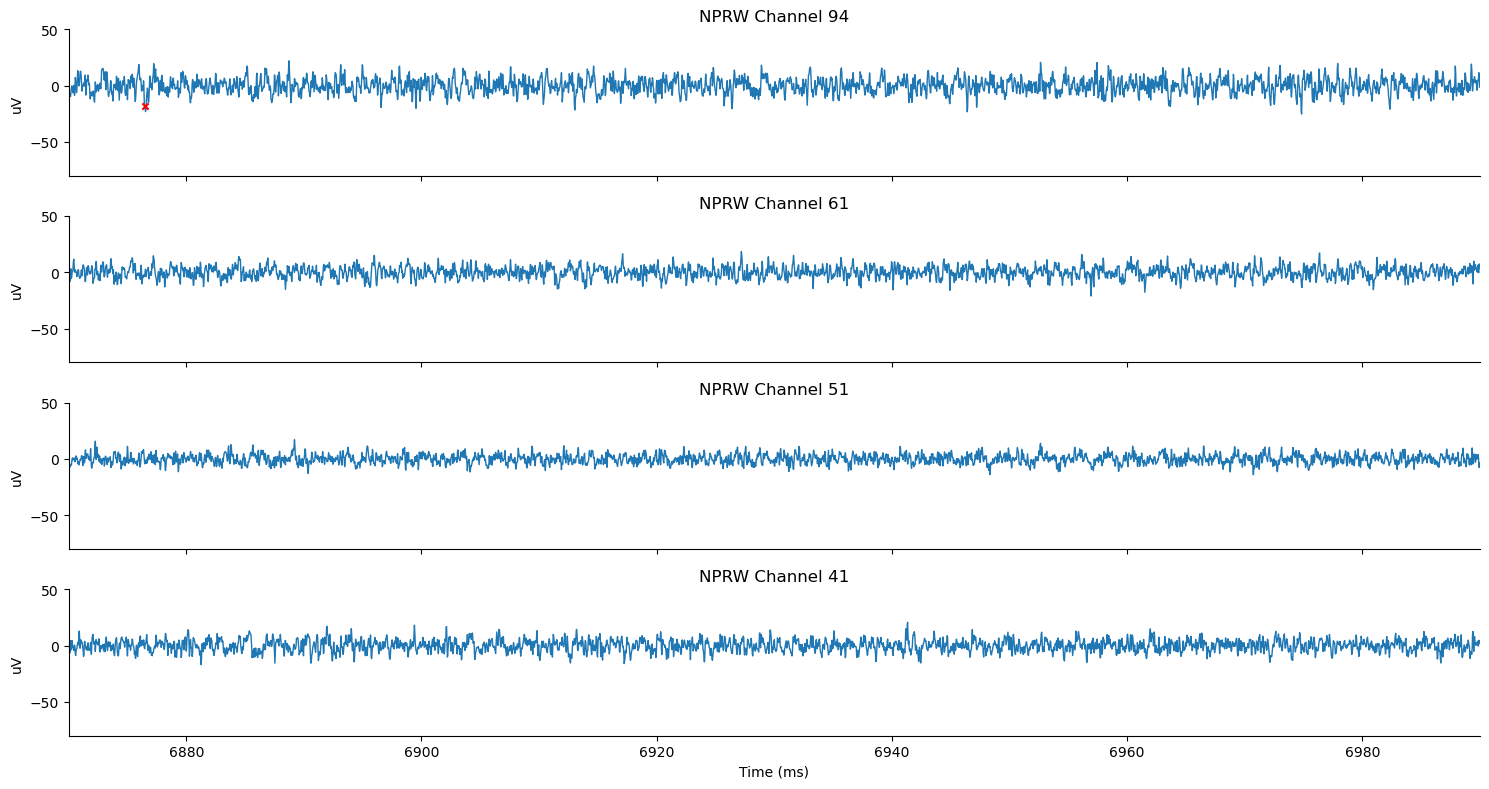

In [33]:
%matplotlib inline

channels = [40, 50, 60, 93] #[68, 69, 70, 71, 72, 73, 74, 75, 76] #[9, 10, 11, 31, 32, 33]

T0_MS = 6870 #4000 # 3948, 8754, 12998, 18264, 22590, 45460, 50684, 55660, 60708, 65530, 70176, 76038
T1_MS = T0_MS + 120
PLOT_SHIFT = 0

fs = fs_nprw = float(rec_nprw.get_sampling_frequency())

i0 = int(T0_MS * fs / 1000.0)
i1 = int(T1_MS * fs / 1000.0)

fig, axes = plt.subplots(len(channels), 1, figsize=(15, 3*len(channels)/1.5), sharex=True)

if len(channels) == 1:
    axes = [axes]

for ax, CH in zip(axes, channels[::-1]):

    ch_id = rec_nprw.get_channel_ids()[CH]

    # Raw trace
    y = rec_nprw.get_traces(
        start_frame=i0,
        end_frame=i1,
        channel_ids=[ch_id],
        return_in_uV=True
    ).squeeze()

    t = (np.arange(i0, i1) / fs) * 1000.0

    # Peak samples
    pk_s = np.asarray(
        nprw_peak_samps_mf.get(CH, nprw_peak_samps_mf.get(np.int64(CH), [])),
        dtype=np.int64
    )

    # Keep peaks inside window
    m = (pk_s >= i0) & (pk_s < i1)
    pk_s_w = pk_s[m]

    # Convert to window-relative indices
    pk_idx = (pk_s_w - i0).astype(int)

    # Convert to ms
    pk_ms_w = (pk_s_w / fs) * 1000.0

    # Sample amplitude directly from raw trace
    pk_y = y[pk_idx + PLOT_SHIFT]

    # Plot
    ax.plot(t, y, lw=1, zorder=1)

    if pk_ms_w.size:
        ax.scatter(
            pk_ms_w+PLOT_SHIFT/30,
            pk_y,
            s=20,
            marker="x",
            color="red", zorder=3
        )

    ax.set_xlim(T0_MS, T1_MS)
    ax.set_ylim(-80, 50)
    ax.set_ylabel("uV")
    ax.set_title(f"NPRW Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

In [34]:
# FR estimate params
BIN_MS = 20.0
SIGMA_MS = 20.0

ir_ms = np.asarray(nprw_peaks_si_obj["ir_ms"], float).ravel()
rates_hz, centers_ms, unit_ids, edges_ms = peri_event_rates_from_peaks_ms(
    peaks_ms=nprw_peak_ms_mf,
    event_times_ms=ir_ms,
    win_ms=(-600, 600),
    bin_ms=BIN_MS,
    sigma_ms=SIGMA_MS,
)

psth_hz = np.nanmean(rates_hz, axis=0)   # (n_units, n_bins)

In [35]:
# z score per unit
mu  = np.nanmean(rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_z = (rates_hz - mu) / sig
psth_z = np.nanmean(rates_z, axis=0)
peak_mask = (centers_ms >= -600) & (centers_ms <= 600)

X = psth_z[:, peak_mask]
t = centers_ms[peak_mask]

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0.1  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_sorted = psth_z[order]

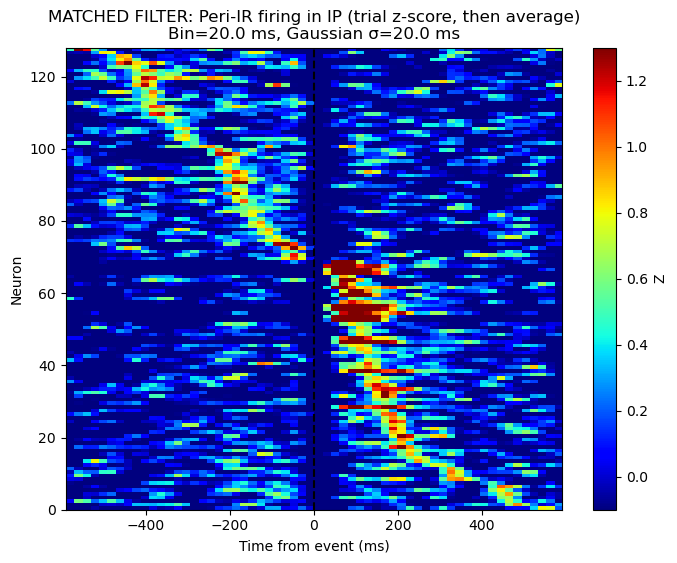

In [36]:
plt.figure(figsize=(8,6))
plt.imshow(
    psth_sorted,
    aspect="auto",
    origin="upper",
    extent=[centers_ms[0], centers_ms[-1], 0, psth_z.shape[0]],
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)
plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Time from event (ms)")
plt.ylabel("Neuron")
plt.title(
    f"MATCHED FILTER: Peri-IR firing in IP (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms"
)
plt.colorbar(label="Z")
plt.show()

# Pipeline output

In [44]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

INDEX = 7

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

# CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
# control_dir = CONTROL_PERI_ROOT / 'target_A'
# control_npz_path = control_dir / FILE
# stim_npz = np.load(control_npz_path, allow_pickle=True)

print(stim_npz)

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_123102
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_123102__bin20ms_sigma20ms.npz
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_123102__BR_008.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...


In [45]:
stim_npz = np.load(stim_npz_path, allow_pickle=True)
rates_ch_hz = stim_npz['NPRW_rates_hz']
edges_ms   = stim_npz["NPRW_edges_ms"]
centers_ms = stim_npz["NPRW_rel_t"]

In [46]:
# z score per channel
mu  = np.nanmean(rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_ch_z = (rates_ch_hz - mu) / sig
psth_z = np.nanmean(rates_ch_z, axis=0)

X = psth_z
t = centers_ms

X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]

In [47]:
def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

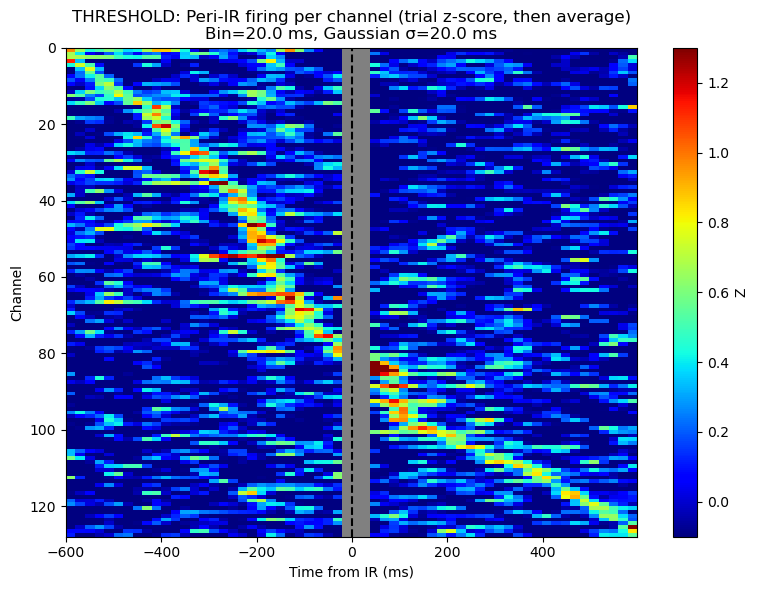

In [ ]:
%matplotlib inline
# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.invert_yaxis()
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"MATCHED_FILTER: Peri-IR firing per channel (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

## Loop through all and save

In [2]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS    = RATES.get("bin_ms")
SIGMA_MS  = RATES.get("sigma_ms")
THRESH    = RATES.get("detect_threshold")
PEAK_SIGN = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"

global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders   = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))

PERI_ROOT       = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"
stim_dir        = STIM_PERI_ROOT

FIG_OUT = OUT_BASE / "figures" / "peri_ir_z_mf"
FIG_OUT.mkdir(parents=True, exist_ok=True)

def _parse_SI_peaks(peaks, n_channels):
    peak_times = {i: np.array([], dtype=np.int64)   for i in range(n_channels)}
    peak_amp   = {i: np.array([], dtype=np.float32) for i in range(n_channels)}
    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii]   = peaks["amplitude"][m]
    return peak_times, peak_amp

def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k
    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")
    out[:, idx] = Z
    return out, centers_from_edges

for INDEX in range(1, 64):
    try:
        if INDEX >= len(nprw_pp_folders) or INDEX >= len(nprw_peaks_folders):
            print(f"[{INDEX:03d}] skipping — index out of range")
            continue

        nprw_pp_folder    = nprw_pp_folders[INDEX]
        nprw_peaks_folder = nprw_peaks_folders[INDEX]

        nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
        SESSION      = nprw_peaks_si_obj['meta'].item()['session']
        session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]

        matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
        if not matches:
            print(f"[{INDEX:03d}] skipping — no peristim file for session {session_name}")
            continue

        stim_npz = np.load(matches[0], allow_pickle=True)
        rates_ch_hz = stim_npz['NPRW_rates_hz']
        edges_ms    = stim_npz["NPRW_edges_ms"]
        centers_ms  = stim_npz["NPRW_rel_t"]

        mu  = np.nanmean(rates_ch_hz, axis=2, keepdims=True)
        sig = np.clip(np.nanstd(rates_ch_hz, axis=2, keepdims=True), 1e-6, None)
        rates_ch_z = (rates_ch_hz - mu) / sig
        psth_z = np.nanmean(rates_ch_z, axis=0)

        X = psth_z
        X_finite     = np.where(np.isfinite(X), X, -np.inf)
        peak_idx     = np.argmax(X_finite, axis=1)
        peak_time_ms = centers_ms[peak_idx]
        peak_val     = np.max(X_finite, axis=1)

        responsive   = np.isfinite(peak_val) & (peak_val >= 0)
        order_resp   = np.argsort(peak_time_ms[responsive])
        order        = np.concatenate([np.where(responsive)[0][order_resp],
                                       np.where(~responsive)[0]])
        psth_ch_sorted = psth_z[order]

        psth_plot, _ = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

        n_ch     = psth_plot.shape[0]
        y_edges  = np.arange(n_ch + 1)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_facecolor("0.5")
        pc = ax.pcolormesh(edges_ms, y_edges, psth_plot,
                           shading="flat", cmap="jet", vmin=-0.1, vmax=1.3)
        ax.invert_yaxis()
        ax.axvline(0, linestyle="--", color="black")
        ax.set_ylim(n_ch, 0)
        ax.set_xlabel("Time from IR (ms)")
        ax.set_ylabel("Channel")
        ax.set_title(f"MATCHED_FILTER: Peri-IR firing per channel (trial z-score, then average)\n"
                     f"Bin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
        fig.colorbar(pc, ax=ax, label="Z")
        plt.tight_layout()

        fig_path = FIG_OUT / f"peristim__NRR_RW{session_name}__BR_{INDEX:03d}__peri_ir_z.png"
        fig.savefig(fig_path, dpi=150)
        plt.close(fig)
        print(f"[{INDEX:03d}] saved -> {fig_path.name}")

    except Exception as e:
        print(f"[{INDEX:03d}] ERROR: {e}")
        plt.close("all")
        continue

Found Intan sessions: 63
[001] saved -> peristim__NRR_RW026_260324_122125__BR_001__peri_ir_z.png
[002] saved -> peristim__NRR_RW026_260324_122305__BR_002__peri_ir_z.png
[003] saved -> peristim__NRR_RW026_260324_122433__BR_003__peri_ir_z.png
[004] saved -> peristim__NRR_RW026_260324_122605__BR_004__peri_ir_z.png
[005] skipping — no peristim file for session 026_260324_122733
[006] saved -> peristim__NRR_RW026_260324_122908__BR_006__peri_ir_z.png
[007] saved -> peristim__NRR_RW026_260324_123102__BR_007__peri_ir_z.png
[008] saved -> peristim__NRR_RW026_260324_123228__BR_008__peri_ir_z.png
[009] saved -> peristim__NRR_RW026_260324_123356__BR_009__peri_ir_z.png
[010] saved -> peristim__NRR_RW026_260324_123541__BR_010__peri_ir_z.png
[011] saved -> peristim__NRR_RW026_260324_123723__BR_011__peri_ir_z.png
[012] saved -> peristim__NRR_RW026_260324_123900__BR_012__peri_ir_z.png
[013] saved -> peristim__NRR_RW026_260324_124036__BR_013__peri_ir_z.png
[014] saved -> peristim__NRR_RW026_260324_12422

PosixPath('/media/bryan/Expansion/Nike/20260324_NRR_RW026')

In [1]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

OUT_BASE_THRESHOLD = OUT_BASE.parent / 'results_threshold'

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS    = RATES.get("bin_ms")
SIGMA_MS  = RATES.get("sigma_ms")
THRESH    = RATES.get("detect_threshold")
PEAK_SIGN = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE_THRESHOLD / "checkpoints" / "NPRW"

global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders   = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))

PERI_ROOT       = OUT_BASE_THRESHOLD / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"
stim_dir        = STIM_PERI_ROOT

FIG_OUT = OUT_BASE_THRESHOLD / "figures" / "peri_ir_z_threshold"
FIG_OUT.mkdir(parents=True, exist_ok=True)

def _parse_SI_peaks(peaks, n_channels):
    peak_times = {i: np.array([], dtype=np.int64)   for i in range(n_channels)}
    peak_amp   = {i: np.array([], dtype=np.float32) for i in range(n_channels)}
    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii]   = peaks["amplitude"][m]
    return peak_times, peak_amp

def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k
    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")
    out[:, idx] = Z
    return out, centers_from_edges

for INDEX in range(1, 64):
    try:
        if INDEX >= len(nprw_pp_folders) or INDEX >= len(nprw_peaks_folders):
            print(f"[{INDEX:03d}] skipping — index out of range")
            continue

        nprw_pp_folder    = nprw_pp_folders[INDEX]
        nprw_peaks_folder = nprw_peaks_folders[INDEX]

        nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
        SESSION      = nprw_peaks_si_obj['meta'].item()['session']
        session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]

        matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
        if not matches:
            print(f"[{INDEX:03d}] skipping — no peristim file for session {session_name}")
            continue

        stim_npz = np.load(matches[0], allow_pickle=True)
        rates_ch_hz = stim_npz['NPRW_rates_hz']
        edges_ms    = stim_npz["NPRW_edges_ms"]
        centers_ms  = stim_npz["NPRW_rel_t"]

        mu  = np.nanmean(rates_ch_hz, axis=2, keepdims=True)
        sig = np.clip(np.nanstd(rates_ch_hz, axis=2, keepdims=True), 1e-6, None)
        rates_ch_z = (rates_ch_hz - mu) / sig
        psth_z = np.nanmean(rates_ch_z, axis=0)

        X = psth_z
        X_finite     = np.where(np.isfinite(X), X, -np.inf)
        peak_idx     = np.argmax(X_finite, axis=1)
        peak_time_ms = centers_ms[peak_idx]
        peak_val     = np.max(X_finite, axis=1)

        responsive   = np.isfinite(peak_val) & (peak_val >= 0)
        order_resp   = np.argsort(peak_time_ms[responsive])
        order        = np.concatenate([np.where(responsive)[0][order_resp],
                                       np.where(~responsive)[0]])
        psth_ch_sorted = psth_z[order]

        psth_plot, _ = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

        n_ch     = psth_plot.shape[0]
        y_edges  = np.arange(n_ch + 1)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.set_facecolor("0.5")
        pc = ax.pcolormesh(edges_ms, y_edges, psth_plot,
                           shading="flat", cmap="jet", vmin=-0.1, vmax=1.3)
        ax.invert_yaxis()
        ax.axvline(0, linestyle="--", color="black")
        ax.set_ylim(n_ch, 0)
        ax.set_xlabel("Time from IR (ms)")
        ax.set_ylabel("Channel")
        ax.set_title(f"MATCHED_FILTER: Peri-IR firing per channel (trial z-score, then average)\n"
                     f"Bin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
        fig.colorbar(pc, ax=ax, label="Z")
        plt.tight_layout()

        fig_path = FIG_OUT / f"peristim__NRR_RW{session_name}__BR_{INDEX:03d}__peri_ir_z.png"
        fig.savefig(fig_path, dpi=150)
        plt.close(fig)
        print(f"[{INDEX:03d}] saved -> {fig_path.name}")

    except Exception as e:
        print(f"[{INDEX:03d}] ERROR: {e}")
        plt.close("all")
        continue

Found Intan sessions: 63
[001] saved -> peristim__NRR_RW026_260324_122125__BR_001__peri_ir_z.png
[002] saved -> peristim__NRR_RW026_260324_122305__BR_002__peri_ir_z.png
[003] saved -> peristim__NRR_RW026_260324_122433__BR_003__peri_ir_z.png
[004] saved -> peristim__NRR_RW026_260324_122605__BR_004__peri_ir_z.png
[005] skipping — no peristim file for session 026_260324_122733
[006] saved -> peristim__NRR_RW026_260324_122908__BR_006__peri_ir_z.png
[007] saved -> peristim__NRR_RW026_260324_123102__BR_007__peri_ir_z.png
[008] saved -> peristim__NRR_RW026_260324_123228__BR_008__peri_ir_z.png
[009] saved -> peristim__NRR_RW026_260324_123356__BR_009__peri_ir_z.png
[010] saved -> peristim__NRR_RW026_260324_123541__BR_010__peri_ir_z.png
[011] saved -> peristim__NRR_RW026_260324_123723__BR_011__peri_ir_z.png
[012] saved -> peristim__NRR_RW026_260324_123900__BR_012__peri_ir_z.png
[013] saved -> peristim__NRR_RW026_260324_124036__BR_013__peri_ir_z.png
[014] saved -> peristim__NRR_RW026_260324_12422